In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import string 
import spacy 
from spacy.lang.pt.stop_words import STOP_WORDS

from tqdm import tqdm 

# Carregar dados

In [4]:
byd=pd.read_csv("BYD.csv",sep=';')
byd['MARCA']=['BYD']*len(byd)
ford=pd.read_csv("FORD.csv",sep=';')
ford['MARCA']=['FORD']*len(ford)
renault=pd.read_csv("RENAULT.csv",sep=';')
renault['MARCA']=['RENAULT']*len(renault)
df=pd.concat([byd,ford,renault],ignore_index=True)
df

,DT_PUBLICACAO,TEXTO,N_CURTIDAS,LINK_PUBLICACAO,DATA_DOWNLOAD,URL_ESP,MARCA
0,2023-09-08,O caminhão BYD eT18 100% elétrico combina 245 ...,136 curtidas,https://www.instagram.com/p/Cw7obPYOA0G/,2024-06-02,https://www.instagram.com/byd_brasil?utm_sourc...,BYD
1,2023-09-12,A BYD possui diversos modelos de empilhadeiras...,80 curtidas,https://www.instagram.com/p/CxGydEoOByf/?img_i...,2024-06-02,https://www.instagram.com/byd_brasil?utm_sourc...,BYD
2,2023-09-13,Com espaço interno otimizado e recarga rápida ...,422 curtidas,https://www.instagram.com/p/CxJNQaWurQH/,2024-06-02,https://www.instagram.com/byd_brasil?utm_sourc...,BYD
3,2023-09-14,Com capacidade para 25 toneladas e recarga com...,85 curtidas,https://www.instagram.com/p/CxLkLCUueAY/,2024-06-02,https://www.instagram.com/byd_brasil?utm_sourc...,BYD
4,2023-09-15,A BYD celebra o Dia do Cliente valorizando cad...,72 curtidas,https://www.instagram.com/p/CxOUjnBO_Wb/,2024-06-02,https://www.instagram.com/byd_brasil?utm_sourc...,BYD
...,...,...,...,...,...,...,...
598,2024-05-31,"O R5 voltou, agora 100% elétrico.\n\no #Renaul...",•,https://www.instagram.com/p/C7odCidBY7x/,2024-06-02,https://www.instagram.com/renaultbrasil?utm_so...,RENAULT
599,2024-05-31,#RolandGarros está recebendo a van autônoma 10...,•,https://www.instagram.com/p/C7pLEAjNAgw/,2024-06-02,https://www.instagram.com/renaultbrasil?utm_so...,RENAULT
600,2024-05-31,"para o Renault 5, não existem regras.\nele est...",•,https://www.instagram.com/p/C7pauwWhDFw/,2024-06-02,https://www.instagram.com/renaultbrasil?utm_so...,RENAULT
601,2024-06-02,uma experiência única da loja #Renault5: o #MA...,•,https://www.instagram.com/p/C7tmhVEqL7b/,2024-06-02,https://www.instagram.com/renaultbrasil?utm_so...,RENAULT


# Embeddings

In [6]:
from sentence_transformers import SentenceTransformer

In [7]:
model = SentenceTransformer("alfaneo/bertimbau-base-portuguese-sts")

In [8]:
textos_marca=list(df['TEXTO'].values)
len(textos_marca)

603

In [9]:
matriz=model.encode(textos_marca)

In [10]:
# visualizar matriz
pd.DataFrame(matriz)

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,-0.574981,0.029332,1.217434,0.243761,0.388861,0.757667,-0.123310,0.266431,0.382434,-0.084312,...,0.068003,0.098880,-1.188491,-0.817572,-0.309310,-0.042370,-0.331373,-0.369221,0.208200,-0.879802
1,-0.442147,0.112745,0.814475,0.204859,0.564463,0.022944,-0.191625,0.164886,0.429808,0.123478,...,0.183776,-0.175139,-1.131684,-0.986262,0.409248,-0.088315,-0.661500,0.191587,-0.229023,-0.682961
2,-0.241126,0.005129,0.709584,-0.263671,0.484188,0.331470,-0.592144,0.026265,0.234738,0.173900,...,0.085690,-0.057805,-1.017988,-0.915592,-0.491081,-0.497441,0.143091,-0.003397,0.381239,-0.925771
3,-0.358578,-0.082713,1.027547,0.297401,0.612600,0.461706,-0.045975,0.015264,0.219999,0.116860,...,-0.059764,-0.077569,-1.080727,-0.812804,-0.265843,-0.338267,-0.239373,-0.224097,0.231468,-0.560696
4,-0.118459,0.217434,0.809154,0.301271,0.824409,-0.001449,-0.275638,-0.585159,0.176073,0.225131,...,-0.010889,-0.761789,-1.368925,-0.959016,-0.196169,-0.294101,-0.477642,0.297294,-0.572555,-0.796397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,-0.201232,0.827215,0.436927,0.143219,0.353183,0.789723,-0.724022,0.533982,0.380752,0.740839,...,0.162807,-0.163735,-0.622526,-1.013370,0.545246,-0.828472,-0.138833,-0.643152,-0.032919,-0.883667
599,-0.201440,0.760570,0.561032,0.050528,0.038961,0.470786,-0.829342,0.230335,0.456776,0.019353,...,-0.215093,0.214621,-1.042918,-0.620320,0.580154,-0.541811,0.052287,-0.504320,-0.111839,-1.432145
600,0.014876,0.760581,0.084521,0.083023,0.088178,0.174551,-0.968902,0.427375,0.354098,0.279843,...,0.732035,0.587151,-1.291890,0.022090,1.073456,-0.606701,-0.490147,-0.336522,-0.443719,-1.392342
601,-0.140183,0.910975,0.547483,-0.421188,-0.122813,0.187173,-0.693157,0.518288,0.299079,1.087650,...,0.125969,-0.267727,-0.422969,-0.688862,-0.036636,-0.487391,0.123377,-0.350001,-0.006823,-0.859564


In [25]:
from sklearn.manifold import TSNE

In [26]:
X = matriz
y=df['MARCA'].values
tse=TSNE(n_components=2, perplexity=10,n_iter=20000,init='random',random_state=42)
X_tse=tse.fit_transform(X)

/home/jlbdearaujo/.local/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


In [28]:
marcas=df["MARCA"].unique()
marcas

array(['BYD', 'FORD', 'RENAULT'], dtype=object)

In [29]:
cores=["blue","red","yellow"]
dic=dict(zip(marcas,cores))
listacor=[dic[v] for v in y]

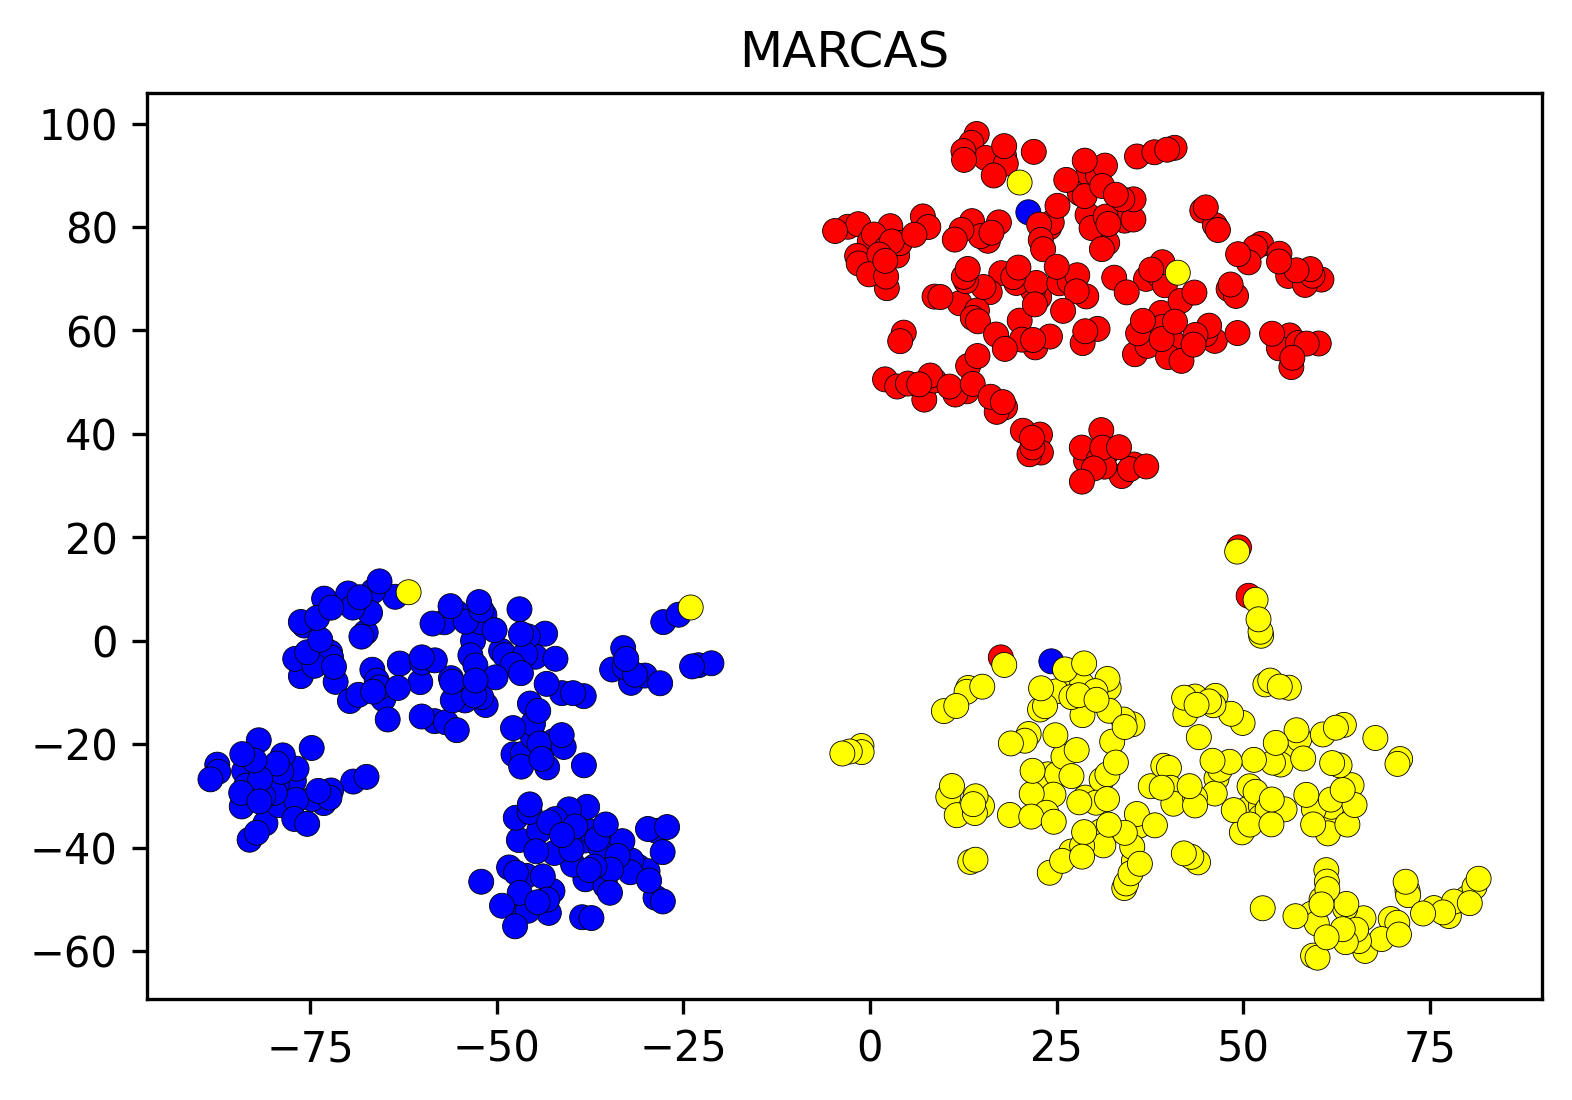

In [30]:
plt.figure(dpi=300)
plt.title("MARCAS")
plt.scatter(X_tse[:,0],X_tse[:,1],c=listacor,edgecolors="black",lw=0.2)

# Criar modelo de IA

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score

In [31]:
# treinar modelo
clf=LogisticRegression(max_iter=10000,random_state=42).fit(X_tse,df['MARCA'].values)

# Performance

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test= train_test_split(X_tse, df['MARCA'].values,test_size=0.3, random_state = 42)
clf = LogisticRegression(max_iter=10000,random_state=42).fit(X_train, y_train)

y_pred=clf.predict(X_test)

print("Acurácia: ", accuracy_score(y_test, y_pred))
print("\nF1-Score:", f1_score(y_test, y_pred, average='weighted'))


Acurácia:  0.994475138121547

F1-Score: 0.9944742410099324


In [35]:
d_teste=pd.DataFrame({'TESTE':y_test,'PRED':y_pred})
d_teste

,TESTE,PRED
0,BYD,BYD
1,RENAULT,RENAULT
2,RENAULT,RENAULT
3,BYD,BYD
4,BYD,BYD
...,...,...
176,RENAULT,RENAULT
177,BYD,BYD
178,BYD,BYD
179,FORD,FORD


In [36]:
print('BYD',len(d_teste[(d_teste['TESTE']=='BYD')&(d_teste['PRED']=='BYD')]) )
print('RENAULT',len(d_teste[(d_teste['TESTE']=='RENAULT')&(d_teste['PRED']=='RENAULT')]) )
print('FORD',len(d_teste[(d_teste['TESTE']=='FORD')&(d_teste['PRED']=='FORD')]) )

BYD 70
RENAULT 56
FORD 54


Text(137.16666666666669, 0.5, 'real')

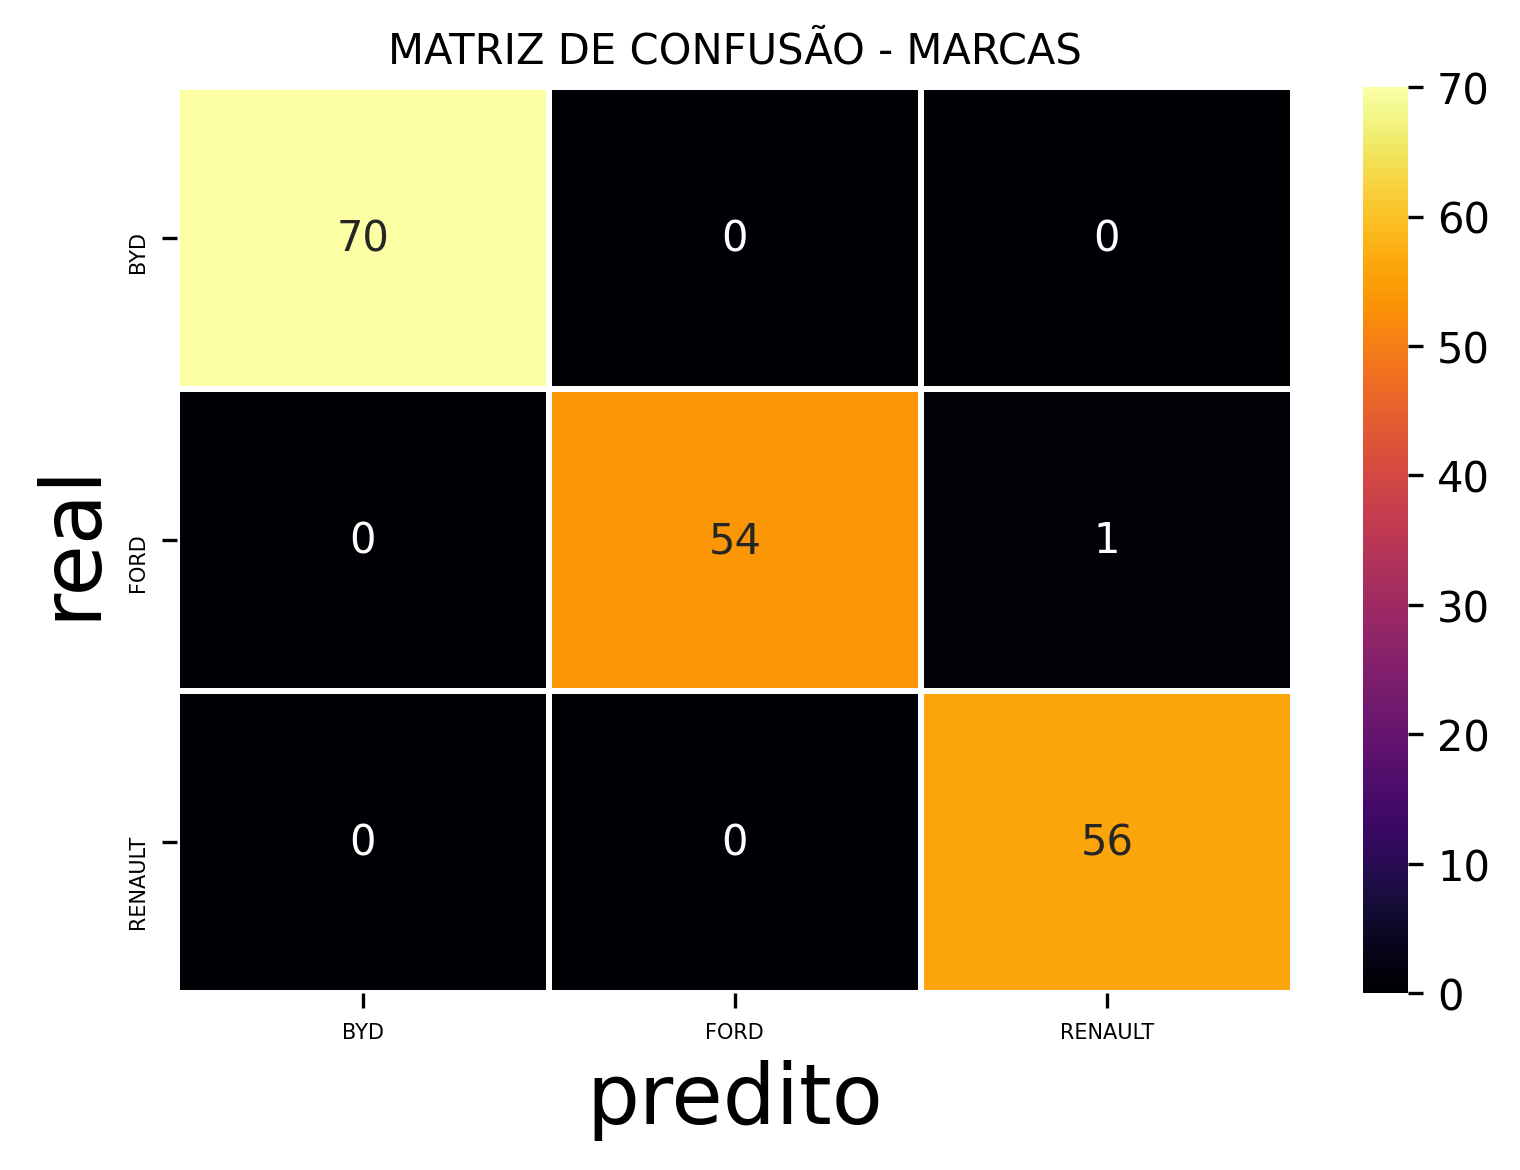

In [38]:
plt.figure(dpi=300)
plt.title('MATRIZ DE CONFUSÃO - MARCAS',fontsize=10)
sns.heatmap(confusion_matrix(d_teste['TESTE'],d_teste['PRED']),annot=True,cmap='inferno',lw=1,annot_kws={"size":10})
plt.xticks([0.5,1.5,2.5],['BYD','FORD','RENAULT'],fontsize=5)
plt.yticks([0.5,1.5,2.5],['BYD','FORD','RENAULT'],fontsize=5)
plt.xlabel('predito',fontsize=20)
plt.ylabel('real',fontsize=20)